In [1]:
# Python packages
import scanpy as sc
import scvi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
sc.settings.verbosity = 3
sc.set_figure_params(dpi=150, fontsize=10, dpi_save=600)
# Set maximum number of jobs for Scanpy.
sc.settings.njobs = 64

# Data

In [2]:
adata = sc.read_mtx("single_cell_rna_matrix.mtx")
adata = adata.transpose()
with open("single_cell_rna_matrix_gene_name.txt") as f:
    adata.var_names = f.read().splitlines()
with open("single_cell_rna_matrix_cell_barcode.txt") as f:
    adata.obs_names = f.read().splitlines()
meta_data = pd.read_csv("single_cell_rna_matrix_meta.csv", sep=',')
meta_data.set_index('Unnamed: 0', inplace=True)
adata.obs = adata.obs.join(meta_data)
# adata.write("path/ro/adata.h5ad")

In [3]:
adata.obsm["X_pca"] = pd.read_csv("pca.csv", index_col=0).values
adata.obsm["X_umap"] = pd.read_csv("umap.csv", index_col=0).values
adata.obsm["X_harmony"] = pd.read_csv("harmony.csv", index_col=0).values

In [26]:
adata.obs["seurat_clusters"] = (
    adata.obs["seurat_clusters"].astype("category")
)

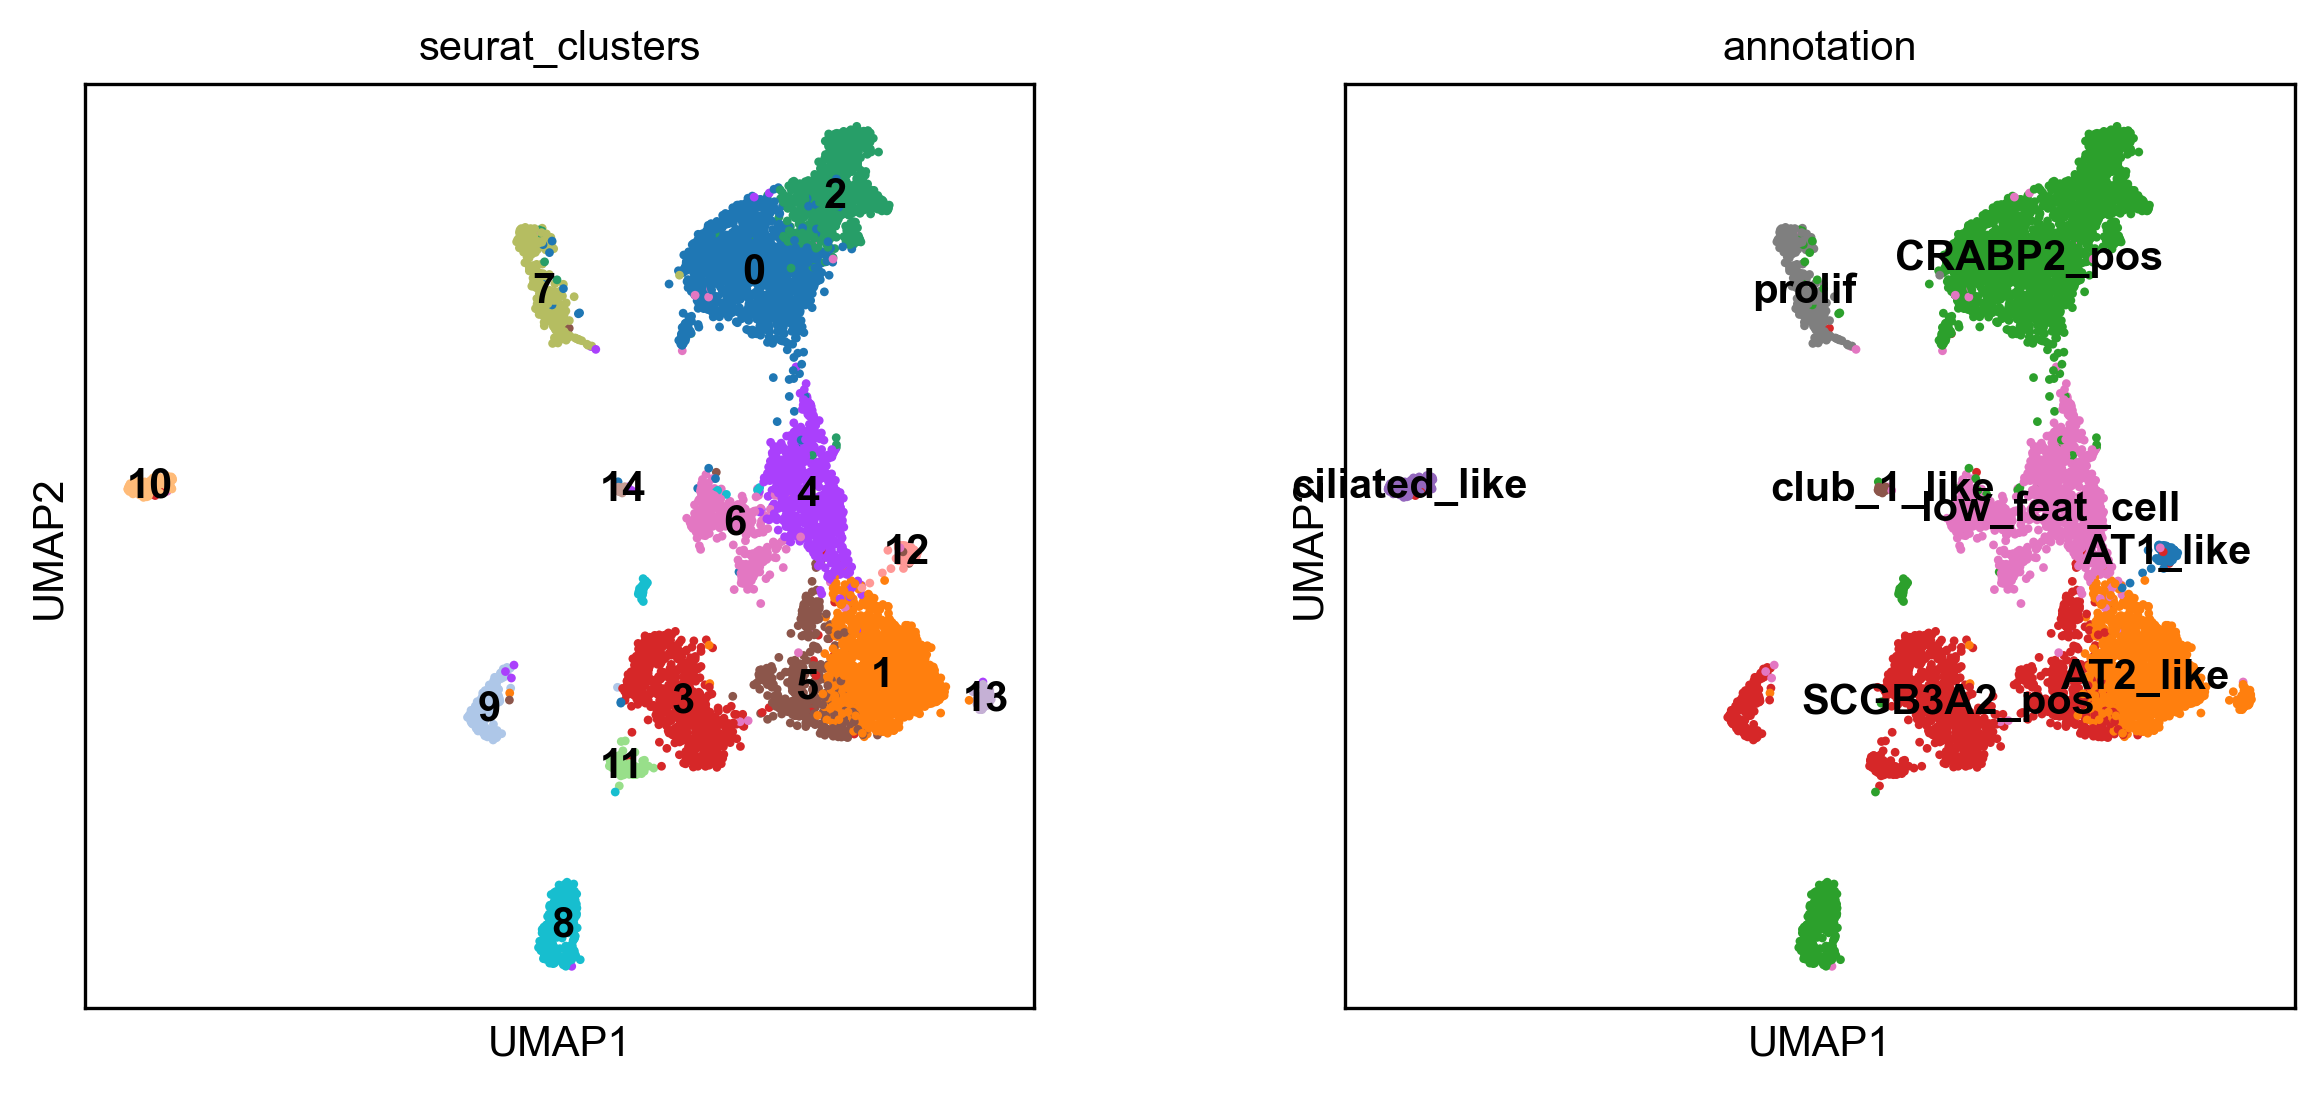

In [27]:
sc.pl.umap(
    adata, 
    color = ["seurat_clusters", "annotation"], 
    legend_loc="on data")

# Process 

In [14]:
adata_filtered = adata[adata.obs["annotation"] .isin([
    "AT2_like", "SCGB3A2_pos", "CRABP2_pos"])].copy()

In [15]:
batch_key = "orig.ident"
adata_filtered.layers["counts"] = adata_filtered.X.copy()
# adata_filtered.X = adata_filtered.layers["counts"].copy()
sc.pp.filter_genes(adata_filtered, min_cells=1)
sc.pp.normalize_total(adata_filtered)
sc.pp.log1p(adata_filtered)
adata_filtered.layers["logcounts"] = adata_filtered.X.copy()

filtered out 5979 genes that are detected in less than 1 cells
normalizing counts per cell
    finished (0:00:00)


In [16]:
sc.pp.highly_variable_genes(
    adata_filtered, n_top_genes=2000, flavor="seurat", batch_key=batch_key
)
adata_filtered_hvg = adata_filtered[:, adata_filtered.var["highly_variable"]].copy()

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [ ]:
batch_key = "orig.ident"
scvi.model.SCVI.setup_anndata(adata_filtered_hvg, layer="counts", batch_key=batch_key)
model_scvi = scvi.model.SCVI(adata_filtered_hvg)
scvi.settings.dl_num_workers = 32
model_scvi.train()

In [18]:
adata_filtered.obsm["X_scVI"] = model_scvi.get_latent_representation()
sc.pp.neighbors(adata_filtered, use_rep="X_scVI")
sc.tl.umap(adata_filtered)

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:05)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:04)


In [ ]:
sc.tl.leiden(adata_filtered, resolution=0.8, key_added="leiden_0.8")

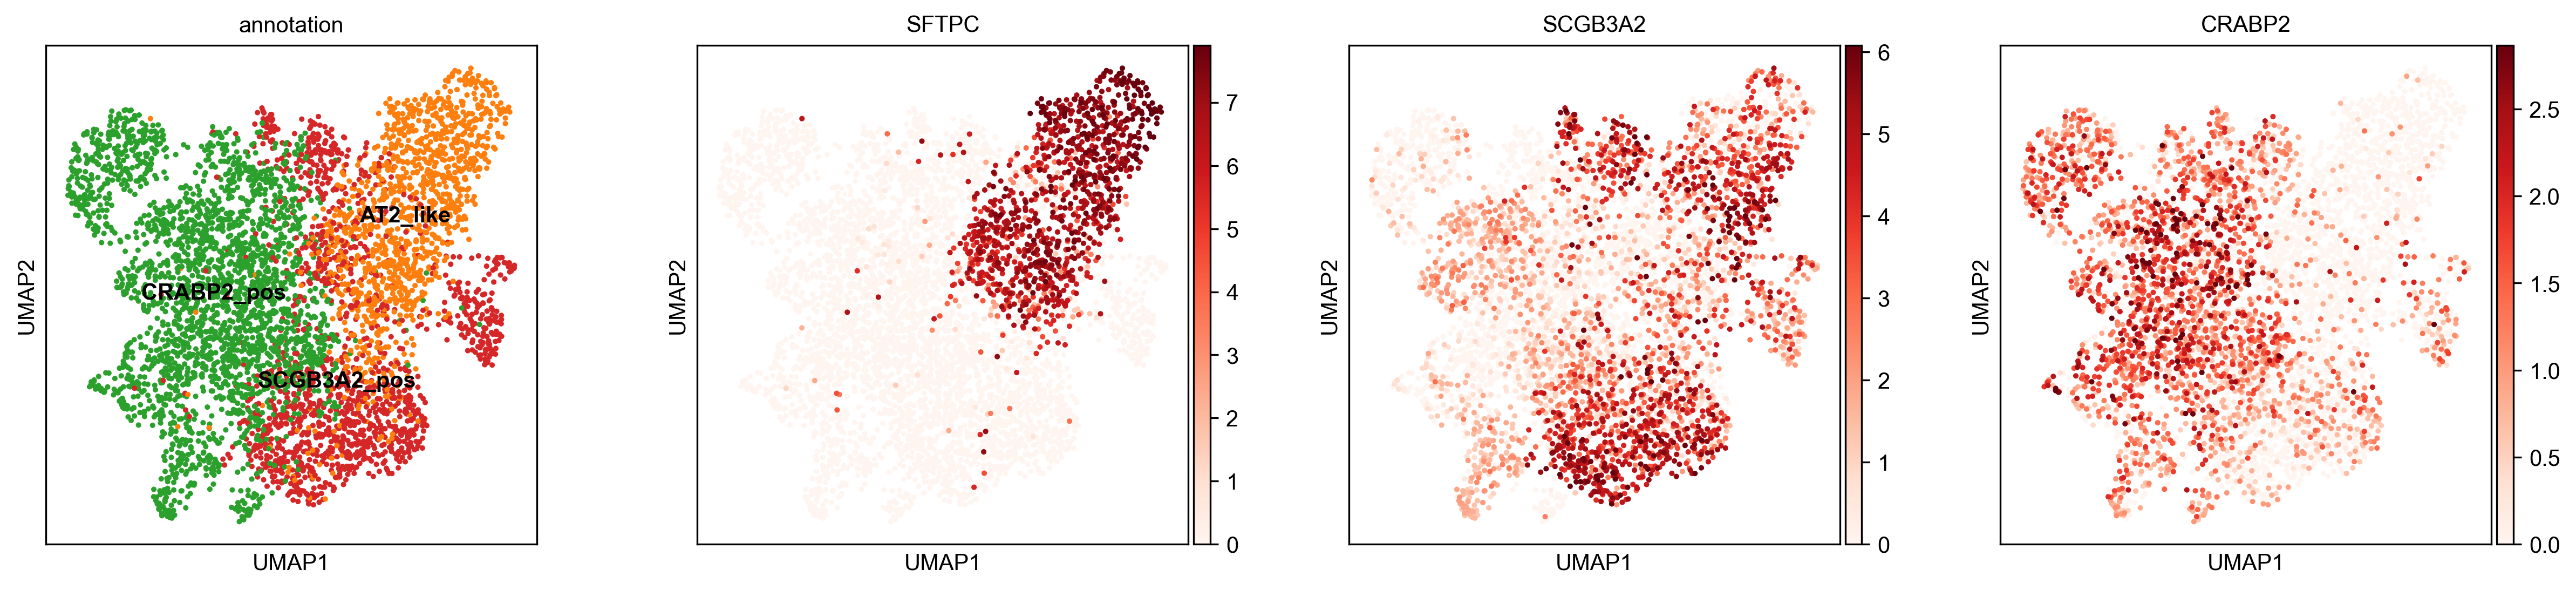

In [20]:
sc.pl.umap(
    adata_filtered, 
    color = [
        "annotation", "SFTPC", "SCGB3A2", "CRABP2"
    ], 
    legend_loc="on data", 
    cmap="Reds",
    vmax="p99",
)


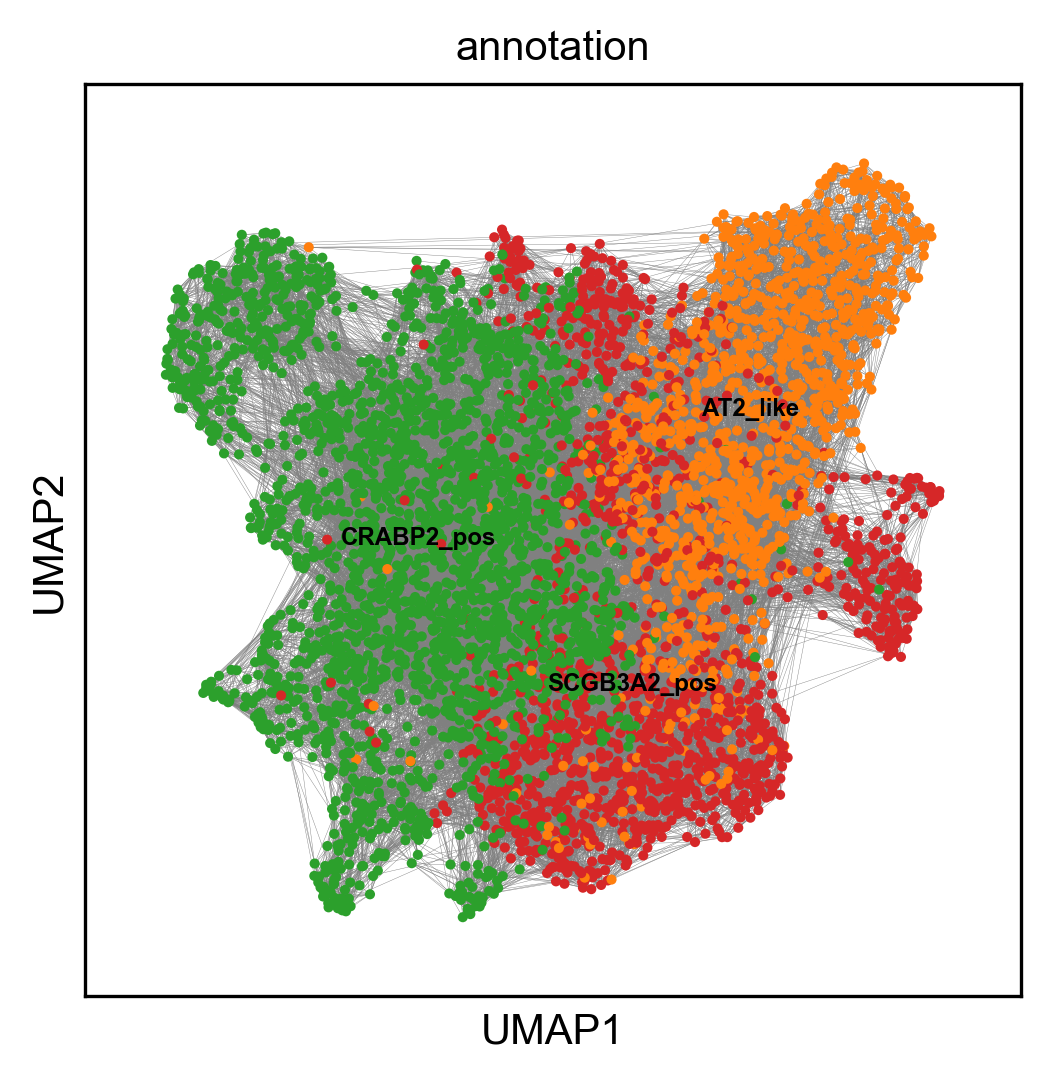

In [21]:
sc.pl.umap(adata_filtered, color = ['annotation'],legend_loc = 'on data', legend_fontsize = 'xx-small', edges = True)

# PAGA 

drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fa', graph_drawing coordinates (adata.obsm) (0:00:11)


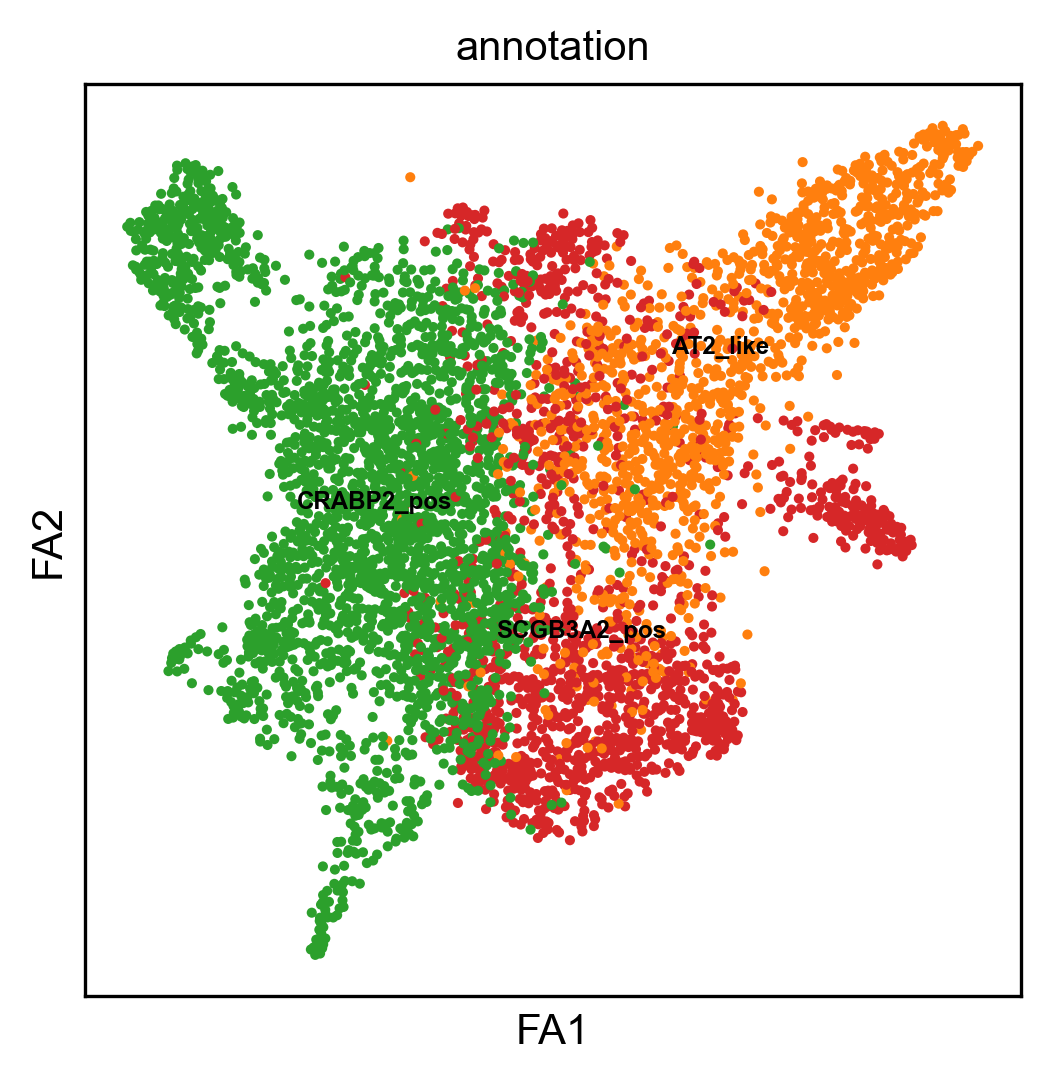

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)
--> added 'pos', the PAGA positions (adata.uns['paga'])


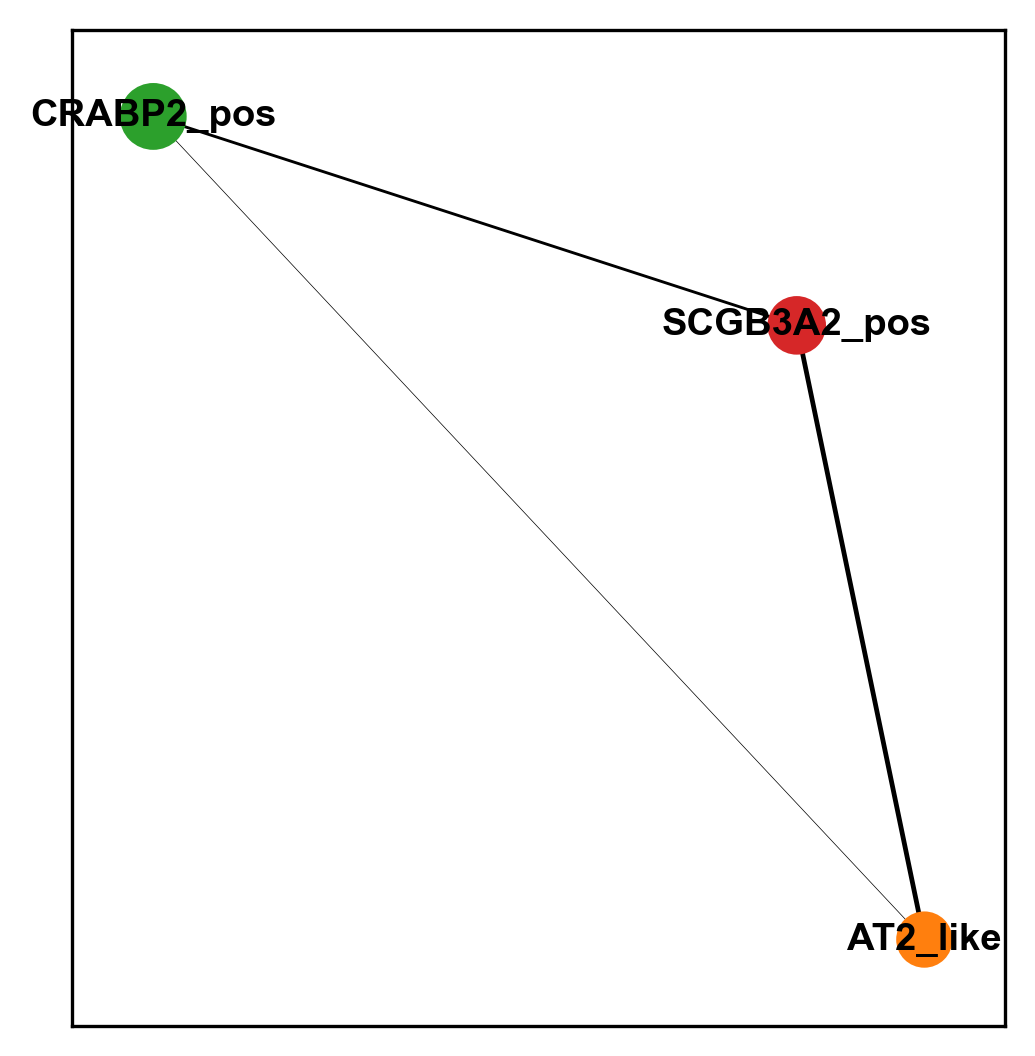

In [23]:
sc.tl.draw_graph(adata_filtered, init_pos='X_umap')
sc.pl.draw_graph(adata_filtered, color='annotation', legend_loc='on data', legend_fontsize = 'xx-small')
sc.tl.paga(adata_filtered, groups='annotation')
sc.pl.paga(adata_filtered, color='annotation', edge_width_scale = 0.3)

--> added 'pos', the PAGA positions (adata.uns['paga'])


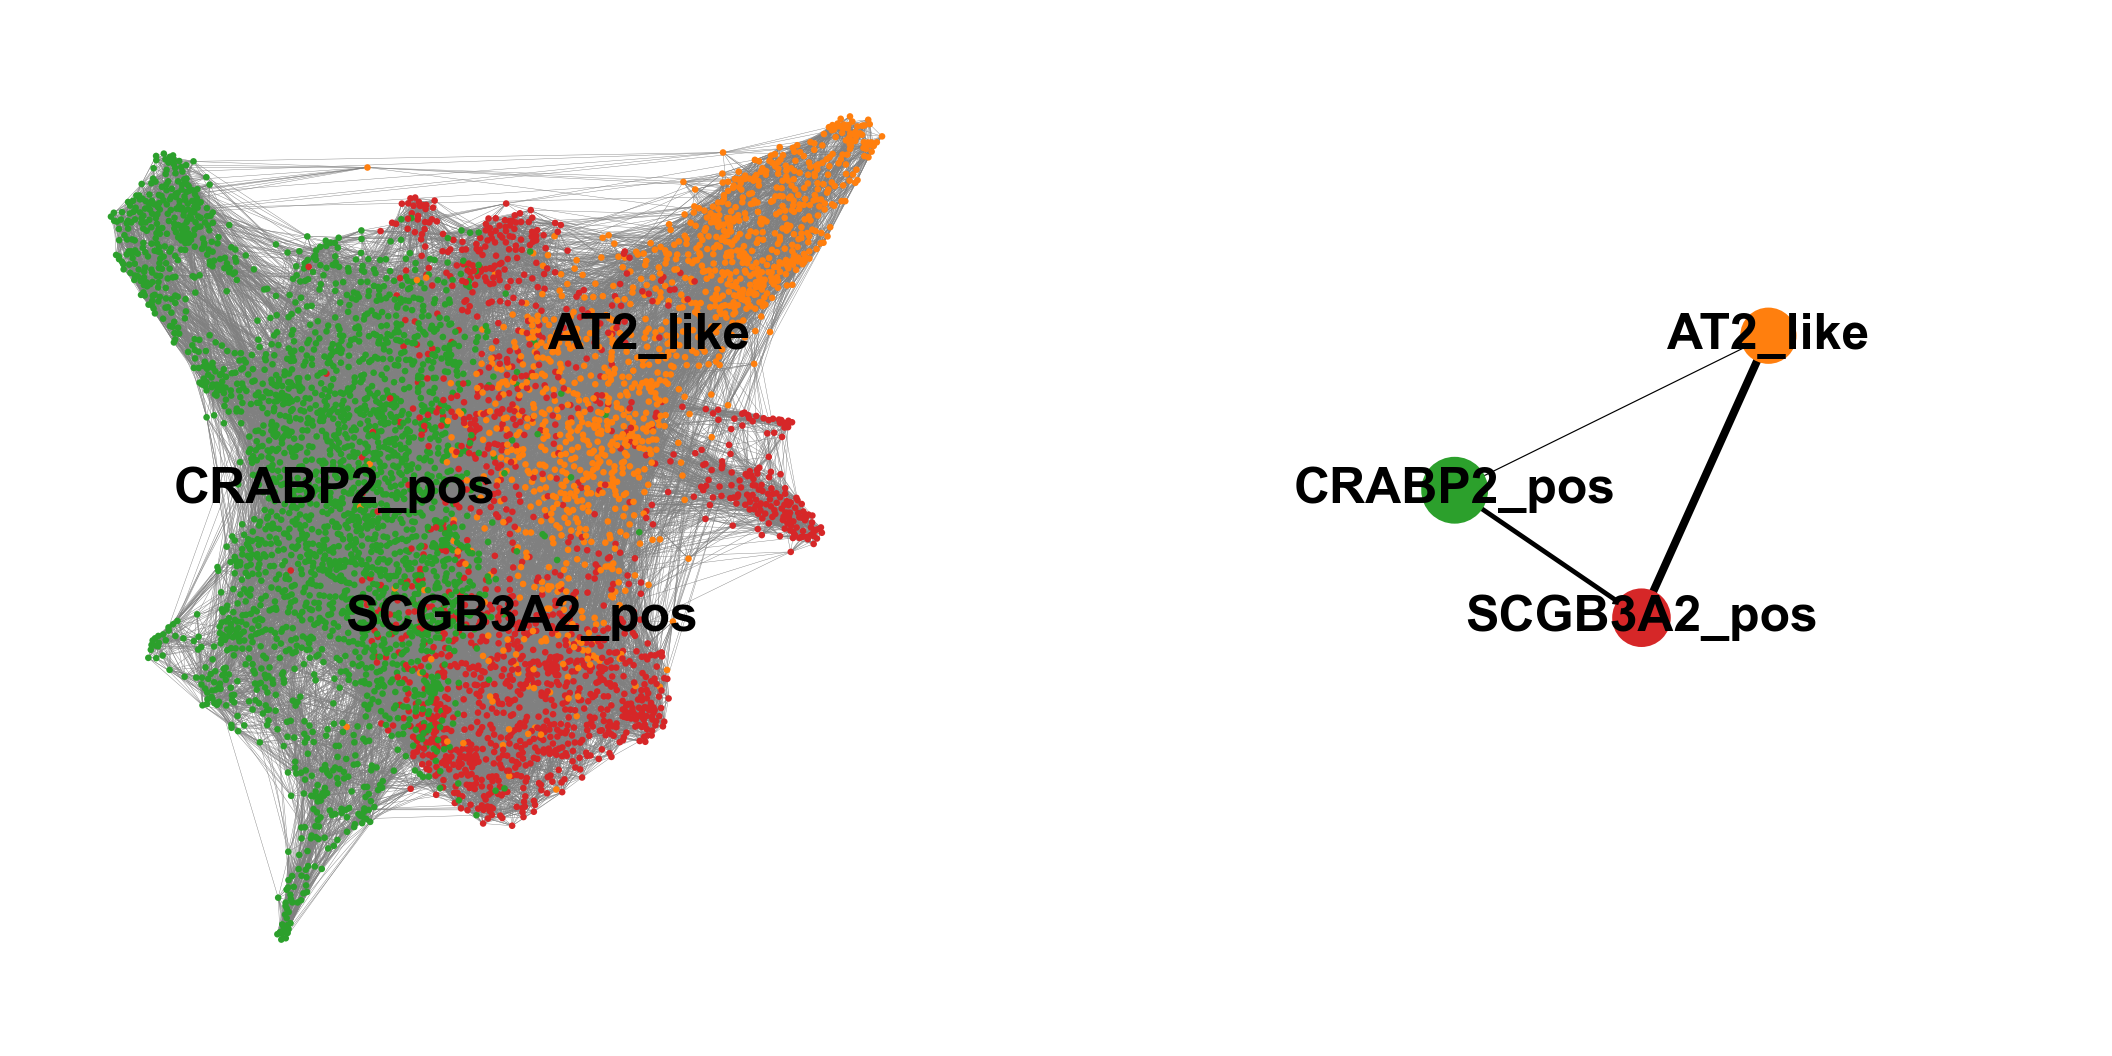

[<Axes: xlabel='FA1', ylabel='FA2'>, <Axes: >]

In [25]:
sc.pl.paga_compare(
    adata_filtered, threshold=0.03, title='', right_margin=0.2, size=10, edge_width_scale=0.5,
    legend_fontsize=12, fontsize=12, frameon=False, edges=True)

In [28]:
import matplotlib.pyplot as plt

sc.pl.paga_compare(
    adata_filtered,
    threshold=0.03,
    title="",
    right_margin=0.2,
    size=10,
    edge_width_scale=0.5,
    legend_fontsize=12,
    fontsize=12,
    frameon=False,
    edges=True,
    show=False
)

plt.savefig(
    "PAGA_compare.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.close()

--> added 'pos', the PAGA positions (adata.uns['paga'])
